
# 🚚 Logistic Regression: Amazon Shipping Type Classification

This notebook demonstrates how to use logistic regression to classify Amazon shipments as **Standard (0)** or **Express (1)** using synthetic data.

### Features:
- `distance_km`, `weight_kg`, `is_fragile`, `item_category_encoded`
- `order_hour`, `is_prime_customer`, `estimated_delivery_days`

### Target:
- `shipping_type`: 0 = Standard, 1 = Express


In [1]:

# --------------------------------------------------
# 1. IMPORT LIBRARIES
# --------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# For reproducibility


In [5]:

# --------------------------------------------------
# 2. DATA GENERATION (SYNTHETIC)
# --------------------------------------------------

url = "https://raw.githubusercontent.com/saikisri97/Optimisation/master/For_AI_Lecture/data/Synthetic_Shipping_Dataset.csv"
df = pd.read_csv(url)
df.head()


,distance_km,weight_kg,is_fragile,item_category_encoded,order_hour,is_prime_customer,estimated_delivery_days,shipping_type
0,752.207537,9.338133,1,2,1,1,5,1
1,1901.675041,27.140857,0,3,8,1,1,1
2,1465.327914,43.659997,0,6,12,1,1,1
3,1199.323676,36.638022,0,2,14,0,1,1
4,316.257188,40.347401,1,8,2,0,6,0


In [6]:

# --------------------------------------------------
# 3. DATA EXPLORATION & PREPROCESSING
# --------------------------------------------------
print("\nData Description:")
print(df.describe())

print("\nClass Distribution:")
print(df['shipping_type'].value_counts())

# No categorical columns to encode; all features are numeric or binary
X = df.drop('shipping_type', axis=1)
y = df['shipping_type']



Data Description:
       distance_km    weight_kg   is_fragile  item_category_encoded  \
count  1000.000000  1000.000000  1000.000000            1000.000000   
mean    983.061824    25.400164     0.489000               4.466000   
std     582.814037    14.580276     0.500129               2.905734   
min      14.240886     0.260591     0.000000               0.000000   
25%     475.766669    12.129606     0.000000               2.000000   
50%     996.130716    25.984822     0.000000               5.000000   
75%    1489.917578    38.047206     1.000000               7.000000   
max    1999.436758    49.970745     1.000000               9.000000   

        order_hour  is_prime_customer  estimated_delivery_days  shipping_type  
count  1000.000000         1000.00000               1000.00000    1000.000000  
mean     12.028000            0.51000                  3.43000       0.644000  
std       6.745867            0.50015                  1.73439       0.479055  
min       0.000000   

In [7]:

# --------------------------------------------------
# 4. SPLIT DATA INTO TRAIN/TEST
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((800, 7), (200, 7), (800,), (200,))

In [8]:

# --------------------------------------------------
# 5. MODEL BUILDING & TRAINING
# --------------------------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Logistic Regression model is trained.")


Logistic Regression model is trained.


In [9]:

# --------------------------------------------------
# 6. EVALUATION
# --------------------------------------------------
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", conf_mat)
print("\nClassification Report:\n", report)


Accuracy: 0.9

Confusion Matrix:
 [[ 56  15]
 [  5 124]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.79      0.85        71
           1       0.89      0.96      0.93       129

    accuracy                           0.90       200
   macro avg       0.91      0.87      0.89       200
weighted avg       0.90      0.90      0.90       200



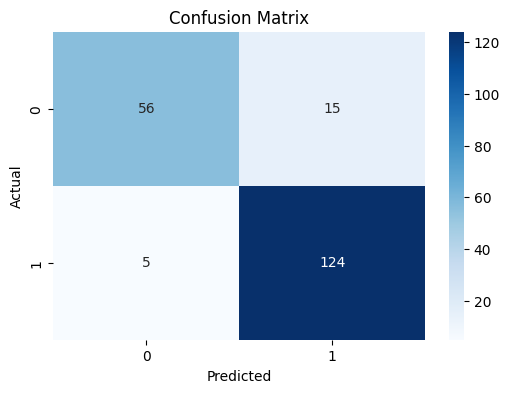

In [10]:

# --------------------------------------------------
# 7. OPTIONAL VISUALIZATION
# --------------------------------------------------
plt.figure(figsize=(6,4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
